# Health Insurance Fraud Detection — Model Explainability & Fraud Intelligence

## Objective

This notebook explains the **frozen production candidate** selected and evaluated in notebooks 04 and 05.

The objective is no longer model selection.

We answer four operational questions:

1. **Which variables drive the fraud-risk model globally?**
2. **Why was a specific claim assigned a high or low risk score?**
3. **Why are some fraud mechanisms easier to detect than others?**
4. **What kinds of legitimate claims are most likely to become false positives?**

### Governance rule

The model is frozen.

No feature selection, hyperparameter tuning, threshold optimization or retraining decision is made from this notebook.

Synthetic metadata such as `fraud_mechanism` and `fraud_difficulty` is used **only after scoring** for diagnostic analysis.

## 1. Imports and project setup

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "interim"

MODEL_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "models"
    / "health_fraud_xgboost.joblib"
)

PREPROCESSOR_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "preprocessors"
    / "health_fraud_preprocessor.joblib"
)

METADATA_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "metadata"
    / "health_fraud_model_metadata.json"
)

EXPLAINABILITY_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "explainability"
)

FIGURES_DIR = (
    EXPLAINABILITY_DIR
    / "figures"
)

EXPLAINABILITY_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

claims = pd.read_parquet(
    DATA_DIR / "claims.parquet"
)

model = joblib.load(
    MODEL_PATH
)

preprocessor = joblib.load(
    PREPROCESSOR_PATH
)

with open(
    METADATA_PATH,
    "r",
    encoding="utf-8",
) as file:
    metadata = json.load(file)

print(f"Claims: {len(claims):,}")
print(f"Model: {metadata['model_name']}")
print(f"Model version: {metadata['model_version']}")
print(f"Feature count in metadata: {metadata['feature_count']}")

Claims: 99,911
Model: XGBoost
Model version: 1.0.0
Feature count in metadata: 57


## 2. Rebuild the exact frozen feature contract

In [2]:
TARGET = "is_fraud"

IDENTIFIER_COLUMNS = [
    "claim_id",
    "customer_id",
    "policy_id",
    "provider_id",
]

LEAKAGE_COLUMNS = [
    "legitimate_anomaly",
    "legitimate_anomaly_type",
    "latent_fraud_score",
    "synthetic_fraud_probability",
    "fraud_difficulty",
    "fraud_mechanism",
]

SYNTHETIC_PROFILE_COLUMNS = [
    "customer_behavior_segment",
    "provider_behavior_segment",
]

RAW_DATE_COLUMNS = [
    "service_date",
    "claim_submission_date",
    "claim_submission_timestamp",
]

# Missingness indicators
claims["has_prescription_missing"] = (
    claims["has_prescription"]
    .isna()
    .astype("int8")
)

claims["document_count_missing"] = (
    claims["document_count"]
    .isna()
    .astype("int8")
)

claims["provider_missing"] = (
    claims["provider_id"]
    .isna()
    .astype("int8")
)

# Calendar features
claims["submission_hour"] = (
    claims["claim_submission_timestamp"]
    .dt.hour
)

claims["submission_dayofweek"] = (
    claims["claim_submission_timestamp"]
    .dt.dayofweek
)

claims["submission_month"] = (
    claims["claim_submission_timestamp"]
    .dt.month
)

claims["submission_is_weekend"] = (
    claims["submission_dayofweek"] >= 5
).astype("int8")

claims["service_dayofweek"] = (
    claims["service_date"]
    .dt.dayofweek
)

claims["service_month"] = (
    claims["service_date"]
    .dt.month
)

claims["service_is_weekend"] = (
    claims["service_dayofweek"] >= 5
).astype("int8")

# Contextual features
EPS = 1e-6

claims["requested_to_limit_ratio"] = (
    claims["requested_reimbursement"]
    / claims["coverage_limit"].clip(lower=EPS)
)

claims["amount_above_service_typical"] = (
    claims["claim_amount"]
    - claims["service_typical_amount"]
)

claims["recent_claim_share_30d_365d"] = (
    claims["customer_claims_30d"]
    / claims["customer_claims_365d"].replace(0, np.nan)
)

claims["recent_amount_share_30d_365d"] = (
    claims["customer_amount_30d"]
    / claims["customer_amount_365d"].replace(0, np.nan)
)

claims["provider_recent_activity_ratio"] = (
    (claims["provider_claims_30d"] + 1)
    / (claims["provider_claims_90d"] / 3 + 1)
)

claims["customer_provider_intensity"] = (
    claims["customer_provider_claims_30d"]
    / (claims["customer_claims_30d"] + 1)
)

claims["same_service_intensity"] = (
    claims["same_service_claims_30d"]
    / (claims["customer_claims_30d"] + 1)
)

claims["days_since_policy_change_missing"] = (
    claims["days_since_policy_change"]
    .isna()
    .astype("int8")
)

FEATURES = metadata["features"]

assert len(FEATURES) == metadata["feature_count"]
assert not set(LEAKAGE_COLUMNS).intersection(FEATURES)
assert not set(IDENTIFIER_COLUMNS).intersection(FEATURES)

print(f"Frozen raw model features: {len(FEATURES)}")
print("Feature contract audit: PASS")

Frozen raw model features: 57
Feature contract audit: PASS


## 3. Restrict explainability analysis to the held-out 2026 test period

In [3]:
TEST_START = pd.Timestamp("2026-01-01")

test = (
    claims.loc[
        claims["claim_submission_timestamp"] >= TEST_START
    ]
    .copy()
    .reset_index(drop=True)
)

X_test_raw = test[FEATURES]

X_test_transformed = (
    preprocessor.transform(
        X_test_raw
    )
)

test_probabilities = (
    model.predict_proba(
        X_test_transformed
    )[:, 1]
)

test["fraud_risk_score"] = (
    test_probabilities
)

print(f"Test claims: {len(test):,}")
print(f"Fraud cases: {int(test[TARGET].sum()):,}")
print(f"Mean fraud risk: {test['fraud_risk_score'].mean():.3%}")

Test claims: 14,176
Fraud cases: 409
Mean fraud risk: 2.771%


## 4. Recover transformed feature names

In [4]:
try:
    transformed_feature_names = (
        preprocessor
        .get_feature_names_out()
        .tolist()
    )
except Exception as exc:
    transformed_feature_names = [
        f"feature_{i}"
        for i in range(
            X_test_transformed.shape[1]
        )
    ]

    print(
        "WARNING: feature names could not be recovered."
    )

    print(exc)

assert (
    len(transformed_feature_names)
    == X_test_transformed.shape[1]
)

print(
    f"Transformed features: "
    f"{len(transformed_feature_names)}"
)

transformed_feature_names[:20]

Transformed features: 107


['service_units',
 'claim_amount',
 'requested_reimbursement',
 'coverage_limit',
 'document_count',
 'customer_age',
 'customer_tenure_months',
 'policy_tenure_months',
 'days_since_policy_change',
 'provider_tenure_months',
 'days_service_to_submission',
 'reimbursement_ratio',
 'customer_claims_7d',
 'customer_claims_30d',
 'customer_claims_90d',
 'customer_claims_365d',
 'customer_amount_30d',
 'customer_amount_365d',
 'customer_avg_claim_amount_365d',
 'days_since_customer_previous_claim']

One-hot encoding expands the original feature space.

Therefore:

- the raw model contract contains the original business variables;
- SHAP operates on the transformed feature matrix actually consumed by XGBoost.

## 5. Build a representative SHAP sample

In [5]:
SHAP_SAMPLE_SIZE = min(
    5000,
    len(test),
)

rng = np.random.default_rng(
    RANDOM_SEED
)

sample_positions = (
    rng.choice(
        len(test),
        size=SHAP_SAMPLE_SIZE,
        replace=False,
    )
)

X_shap = (
    X_test_transformed[
        sample_positions
    ]
)

test_shap = (
    test.iloc[
        sample_positions
    ]
    .reset_index(drop=True)
)

print(f"SHAP sample size: {len(test_shap):,}")
print(
    f"Fraud prevalence in SHAP sample: "
    f"{test_shap[TARGET].mean():.3%}"
)

SHAP sample size: 5,000
Fraud prevalence in SHAP sample: 3.000%


A representative sample is used to keep execution time reasonable.

This does not affect model predictions; it only limits the number of rows for explanation computation.

## 6. Compute SHAP values

In [6]:
explainer = shap.TreeExplainer(
    model
)

shap_values = explainer(
    X_shap
)

shap_values.feature_names = (
    transformed_feature_names
)

print(
    f"SHAP matrix: "
    f"{shap_values.values.shape}"
)

SHAP matrix: (5000, 107)


## 7. Global SHAP importance

In [7]:
global_importance = pd.DataFrame(
    {
        "feature": transformed_feature_names,
        "mean_abs_shap": np.abs(
            shap_values.values
        ).mean(axis=0),
        "mean_shap": (
            shap_values.values
            .mean(axis=0)
        ),
    }
)

global_importance = (
    global_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

global_importance.head(30)

,feature,mean_abs_shap,mean_shap
0,claim_to_service_median_ratio,0.2968,-0.0972
1,days_since_customer_previous_claim,0.2614,-0.1422
2,reimbursement_ratio,0.2134,-0.0098
3,provider_claims_30d,0.1923,-0.0902
4,submission_month,0.1174,-0.0714
5,amount_above_service_typical,0.0969,-0.0331
6,requested_to_limit_ratio,0.0960,-0.0315
7,same_service_claims_30d,0.0955,-0.0474
8,customer_claims_30d,0.0946,-0.0562
9,customer_provider_claims_30d,0.0851,-0.0474


In [8]:
global_importance.to_csv(
    EXPLAINABILITY_DIR
    / "global_feature_importance.csv",
    index=False,
)

print(
    "Saved global_feature_importance.csv"
)

Saved global_feature_importance.csv


## 8. Global SHAP bar plot

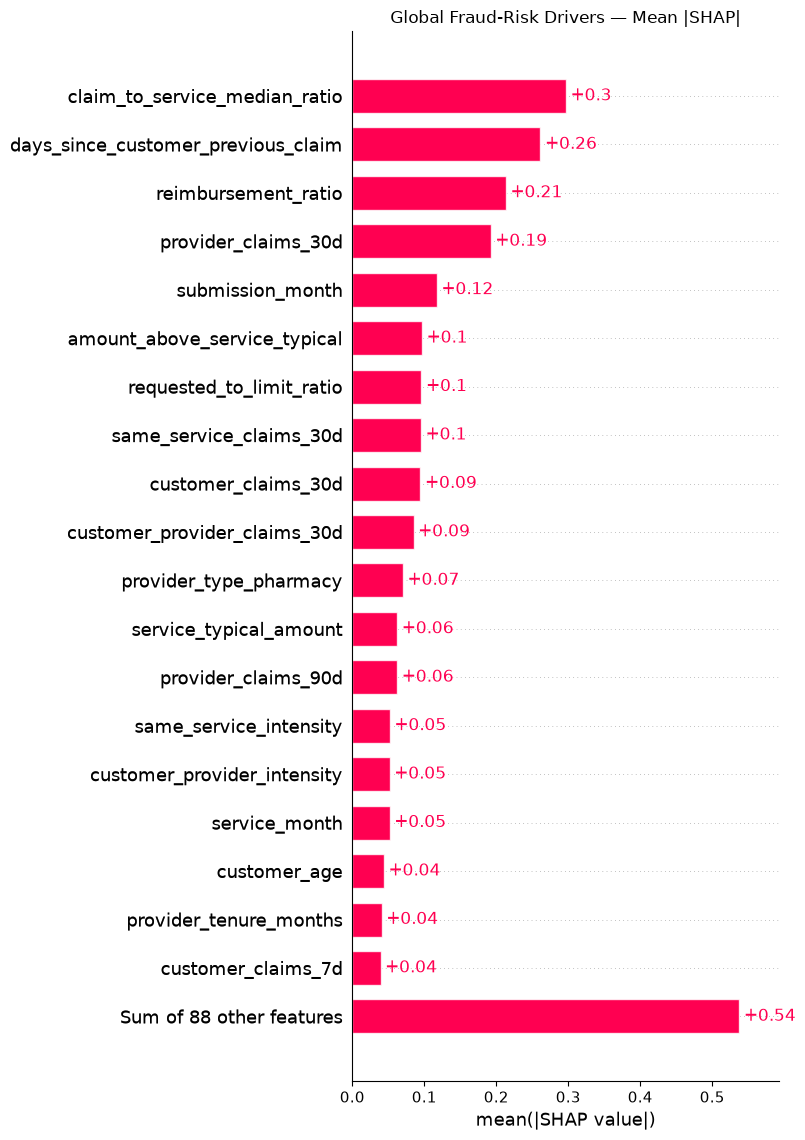

In [9]:
plt.figure(
    figsize=(10, 7)
)

shap.plots.bar(
    shap_values,
    max_display=20,
    show=False,
)

plt.title(
    "Global Fraud-Risk Drivers — Mean |SHAP|"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "01_shap_global_bar.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 9. SHAP beeswarm — magnitude and direction

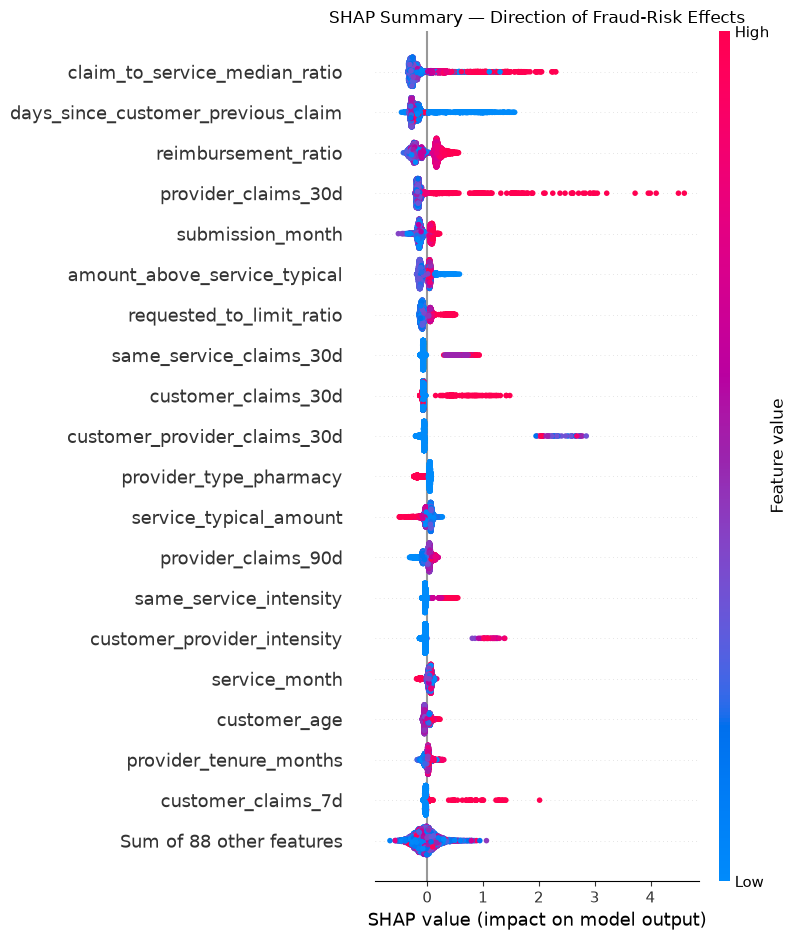

In [10]:
plt.figure(
    figsize=(11, 8)
)

shap.plots.beeswarm(
    shap_values,
    max_display=20,
    show=False,
)

plt.title(
    "SHAP Summary — Direction of Fraud-Risk Effects"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "02_shap_beeswarm.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

Interpretation:

- positive SHAP values push a claim toward higher fraud risk;
- negative SHAP values reduce the predicted fraud risk;
- the beeswarm shows both **importance** and **direction**.

## 10. Aggregate one-hot encoded features back to business concepts

In [11]:
def business_feature_name(
    transformed_name: str,
) -> str:
    raw_candidates = sorted(
        FEATURES,
        key=len,
        reverse=True,
    )

    for raw_name in raw_candidates:
        if (
            transformed_name == raw_name
            or transformed_name.startswith(
                raw_name + "_"
            )
        ):
            return raw_name

    return transformed_name


global_importance[
    "business_feature"
] = (
    global_importance[
        "feature"
    ]
    .map(
        business_feature_name
    )
)

business_importance = (
    global_importance
    .groupby(
        "business_feature",
        as_index=False,
    )
    .agg(
        mean_abs_shap=(
            "mean_abs_shap",
            "sum",
        ),
        signed_mean_shap=(
            "mean_shap",
            "sum",
        ),
    )
    .sort_values(
        "mean_abs_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

business_importance.head(25)

,business_feature,mean_abs_shap,signed_mean_shap
0,claim_to_service_median_ratio,0.2968,-0.0972
1,days_since_customer_previous_claim,0.2614,-0.1422
2,reimbursement_ratio,0.2134,-0.0098
3,provider_claims_30d,0.1923,-0.0902
4,submission_month,0.1174,-0.0714
5,amount_above_service_typical,0.0969,-0.0331
6,requested_to_limit_ratio,0.0960,-0.0315
7,same_service_claims_30d,0.0955,-0.0474
8,customer_claims_30d,0.0946,-0.0562
9,provider_type,0.0863,-0.0019


In [12]:
business_importance.to_csv(
    EXPLAINABILITY_DIR
    / "business_feature_importance.csv",
    index=False,
)

## 11. Business-level importance plot

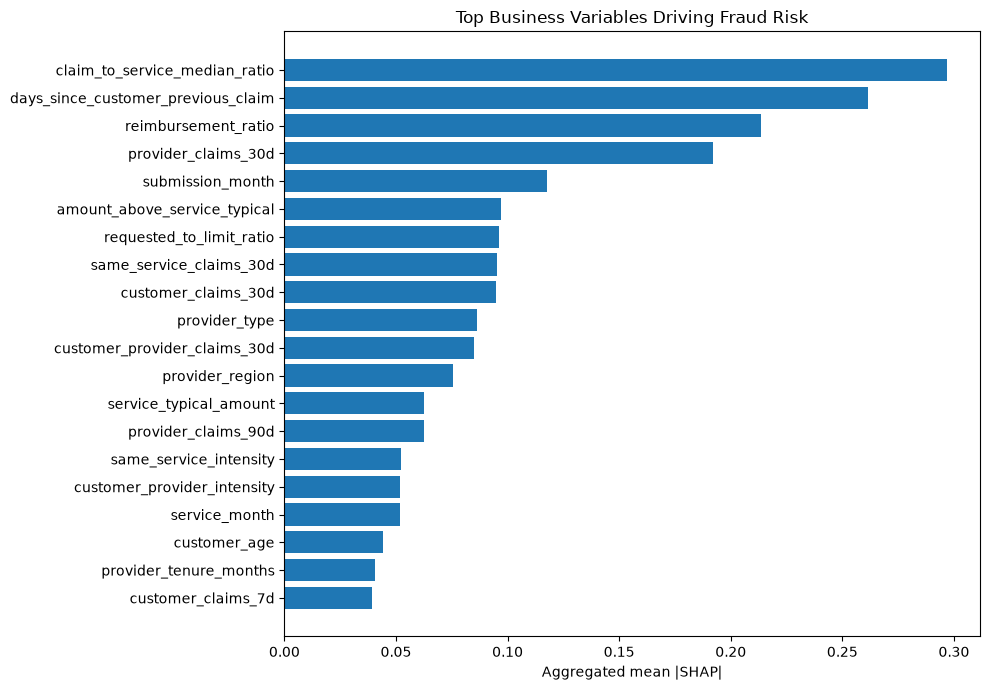

In [13]:
top_business = (
    business_importance
    .head(20)
    .sort_values(
        "mean_abs_shap",
        ascending=True,
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    top_business[
        "business_feature"
    ],
    top_business[
        "mean_abs_shap"
    ],
)

ax.set_title(
    "Top Business Variables Driving Fraud Risk"
)

ax.set_xlabel(
    "Aggregated mean |SHAP|"
)

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "03_business_feature_importance.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 12. Compare model scores across fraud mechanisms

In [14]:
mechanism_score_summary = (
    test.loc[
        test[TARGET] == 1
    ]
    .groupby(
        "fraud_mechanism"
    )
    .agg(
        fraud_claims=(
            TARGET,
            "size",
        ),
        mean_score=(
            "fraud_risk_score",
            "mean",
        ),
        median_score=(
            "fraud_risk_score",
            "median",
        ),
        p25_score=(
            "fraud_risk_score",
            lambda s: s.quantile(0.25),
        ),
        p75_score=(
            "fraud_risk_score",
            lambda s: s.quantile(0.75),
        ),
    )
    .sort_values(
        "median_score",
        ascending=False,
    )
)

mechanism_score_summary

,fraud_claims,mean_score,median_score,p25_score,p75_score
fraud_mechanism,,,,,
customer_provider_pattern,66,0.7863,0.9770,0.9492,0.9890
mixed_pattern,68,0.5136,0.5448,0.0141,0.9845
repeated_service,58,0.4874,0.4352,0.0539,0.9669
frequency_abuse,71,0.3084,0.2292,0.0343,0.4530
provider_abnormality,71,0.2693,0.1772,0.0309,0.4884
amount_inflation,75,0.0372,0.0200,0.0109,0.0434


This table should be compared with notebook 05.

Particular attention should be paid to `amount_inflation`, which was the weakest fraud mechanism under the 3% review policy.

## 13. Compare model scores by fraud difficulty

In [15]:
difficulty_score_summary = (
    test.loc[
        test[TARGET] == 1
    ]
    .groupby(
        "fraud_difficulty"
    )
    .agg(
        fraud_claims=(
            TARGET,
            "size",
        ),
        mean_score=(
            "fraud_risk_score",
            "mean",
        ),
        median_score=(
            "fraud_risk_score",
            "median",
        ),
    )
    .sort_values(
        "median_score",
        ascending=False,
    )
)

difficulty_score_summary

,fraud_claims,mean_score,median_score
fraud_difficulty,,,
easy,113,0.5577,0.6707
medium,220,0.3811,0.2050
hard,76,0.1583,0.0261


## 14. Rebuild top-3% investigation decisions

In [16]:
REVIEW_FRACTION = 0.03

n_review = max(
    1,
    int(
        np.ceil(
            len(test)
            * REVIEW_FRACTION
        )
    ),
)

ranked_positions = np.argsort(
    -test_probabilities
)

reviewed_positions = (
    ranked_positions[:n_review]
)

test[
    "reviewed_top3"
] = False

test.loc[
    reviewed_positions,
    "reviewed_top3",
] = True

print(
    f"Reviewed claims: "
    f"{test['reviewed_top3'].sum():,}"
)

Reviewed claims: 426


## 15. Define explanation cases

In [17]:
true_positive_candidates = (
    test.loc[
        (test[TARGET] == 1)
        & (test["reviewed_top3"])
    ]
    .sort_values(
        "fraud_risk_score",
        ascending=False,
    )
)

false_positive_candidates = (
    test.loc[
        (test[TARGET] == 0)
        & (test["reviewed_top3"])
    ]
    .sort_values(
        "fraud_risk_score",
        ascending=False,
    )
)

false_negative_candidates = (
    test.loc[
        (test[TARGET] == 1)
        & (~test["reviewed_top3"])
    ]
    .sort_values(
        "fraud_risk_score",
        ascending=True,
    )
)

legitimate_anomaly_candidates = (
    test.loc[
        (test[TARGET] == 0)
        & (
            test[
                "legitimate_anomaly"
            ]
        )
    ]
    .sort_values(
        "fraud_risk_score",
        ascending=False,
    )
)

hard_fraud_candidates = (
    test.loc[
        (test[TARGET] == 1)
        & (
            test[
                "fraud_difficulty"
            ]
            == "hard"
        )
    ]
    .sort_values(
        "fraud_risk_score",
        ascending=False,
    )
)

print(
    "TP candidates:",
    len(true_positive_candidates),
)

print(
    "FP candidates:",
    len(false_positive_candidates),
)

print(
    "FN candidates:",
    len(false_negative_candidates),
)

print(
    "Legitimate anomaly candidates:",
    len(legitimate_anomaly_candidates),
)

print(
    "Hard fraud candidates:",
    len(hard_fraud_candidates),
)

TP candidates: 220
FP candidates: 206
FN candidates: 189
Legitimate anomaly candidates: 589
Hard fraud candidates: 76


## 16. Select representative individual cases

In [18]:
case_definitions = []

if len(true_positive_candidates):
    case_definitions.append(
        (
            "true_positive_high_risk",
            int(
                true_positive_candidates
                .index[0]
            ),
        )
    )

if len(false_positive_candidates):
    case_definitions.append(
        (
            "false_positive",
            int(
                false_positive_candidates
                .index[0]
            ),
        )
    )

if len(false_negative_candidates):
    case_definitions.append(
        (
            "false_negative",
            int(
                false_negative_candidates
                .index[0]
            ),
        )
    )

if len(legitimate_anomaly_candidates):
    case_definitions.append(
        (
            "legitimate_anomaly",
            int(
                legitimate_anomaly_candidates
                .index[0]
            ),
        )
    )

if len(hard_fraud_candidates):
    case_definitions.append(
        (
            "hard_fraud",
            int(
                hard_fraud_candidates
                .index[0]
            ),
        )
    )

case_definitions

[('true_positive_high_risk', 12249),
 ('false_positive', 11263),
 ('false_negative', 6379),
 ('legitimate_anomaly', 11263),
 ('hard_fraud', 14174)]

## 17. Helper for individual SHAP explanations

In [19]:
def explain_case(
    case_name: str,
    row_position: int,
    max_display: int = 15,
):
    raw_row = (
        test.loc[
            [row_position],
            FEATURES,
        ]
    )

    transformed_row = (
        preprocessor.transform(
            raw_row
        )
    )

    local_shap = (
        explainer(
            transformed_row
        )
    )

    local_shap.feature_names = (
        transformed_feature_names
    )

    prediction = float(
        model.predict_proba(
            transformed_row
        )[0, 1]
    )

    case_metadata = (
        test.loc[
            row_position,
            [
                "claim_id",
                TARGET,
                "fraud_mechanism",
                "fraud_difficulty",
                "legitimate_anomaly",
                "legitimate_anomaly_type",
                "claim_amount",
            ],
        ]
        .to_dict()
    )

    case_metadata[
        "fraud_risk_score"
    ] = prediction

    print(
        "=" * 72
    )

    print(
        case_name.upper()
    )

    print(
        "=" * 72
    )

    for key, value in (
        case_metadata.items()
    ):
        print(
            f"{key:<28} {value}"
        )

    shap.plots.waterfall(
        local_shap[0],
        max_display=max_display,
        show=False,
    )

    plt.title(
        f"{case_name} — "
        f"risk={prediction:.2%}"
    )

    plt.tight_layout()

    output_path = (
        FIGURES_DIR
        / f"case_{case_name}.png"
    )

    plt.savefig(
        output_path,
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()

    feature_contributions = pd.DataFrame(
        {
            "feature": transformed_feature_names,
            "shap_value": (
                local_shap.values[0]
            ),
            "abs_shap": np.abs(
                local_shap.values[0]
            ),
        }
    )

    feature_contributions = (
        feature_contributions
        .sort_values(
            "abs_shap",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    return (
        case_metadata,
        feature_contributions,
    )

## 18. Generate individual explanations

TRUE_POSITIVE_HIGH_RISK
claim_id                     CLM_00080394
is_fraud                     1
fraud_mechanism              mixed_pattern
fraud_difficulty             medium
legitimate_anomaly           False
legitimate_anomaly_type      none
claim_amount                 321.35
fraud_risk_score             0.9980360865592957


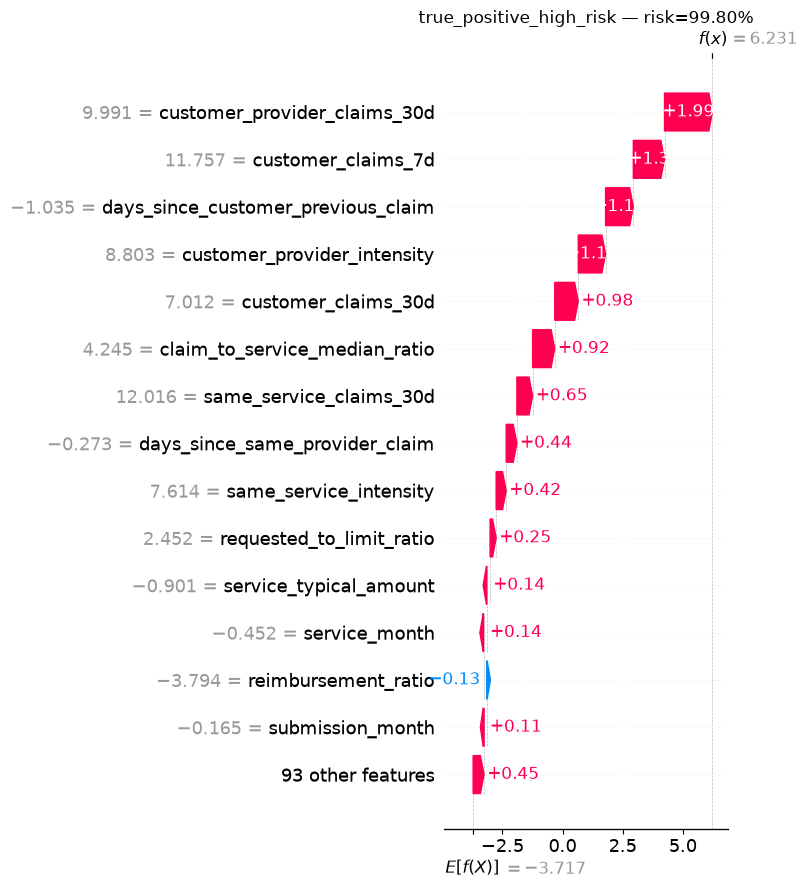

FALSE_POSITIVE
claim_id                     CLM_00048120
is_fraud                     0
fraud_mechanism              none
fraud_difficulty             none
legitimate_anomaly           True
legitimate_anomaly_type      repeated_service_legitimate
claim_amount                 70.77
fraud_risk_score             0.984875500202179


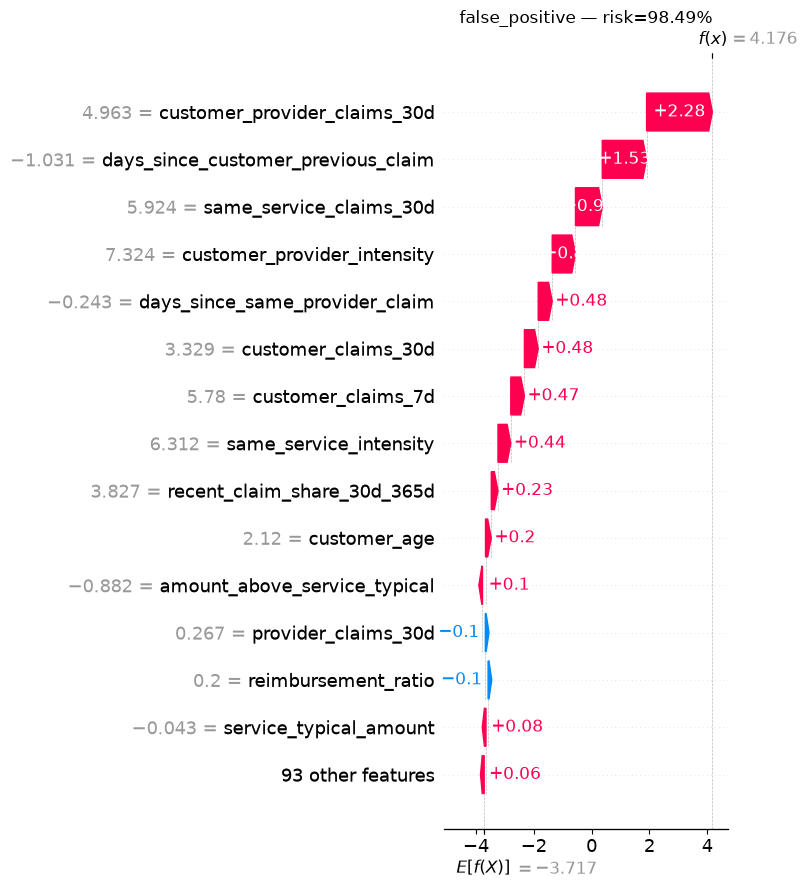

FALSE_NEGATIVE
claim_id                     CLM_00090682
is_fraud                     1
fraud_mechanism              repeated_service
fraud_difficulty             easy
legitimate_anomaly           False
legitimate_anomaly_type      none
claim_amount                 565.24
fraud_risk_score             0.0031129554845392704


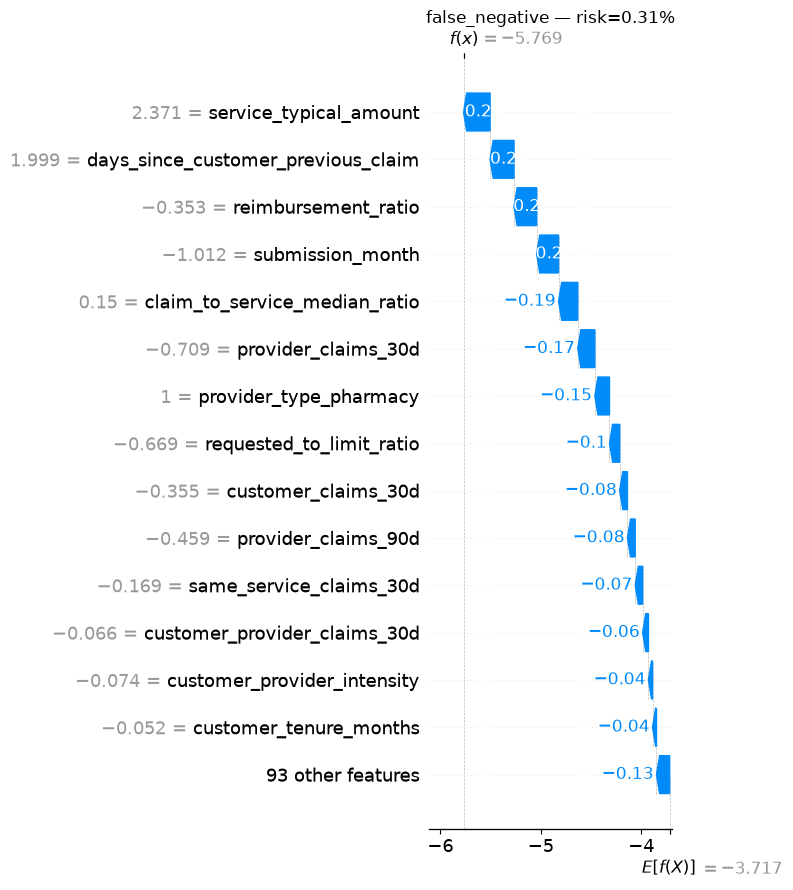

LEGITIMATE_ANOMALY
claim_id                     CLM_00048120
is_fraud                     0
fraud_mechanism              none
fraud_difficulty             none
legitimate_anomaly           True
legitimate_anomaly_type      repeated_service_legitimate
claim_amount                 70.77
fraud_risk_score             0.984875500202179


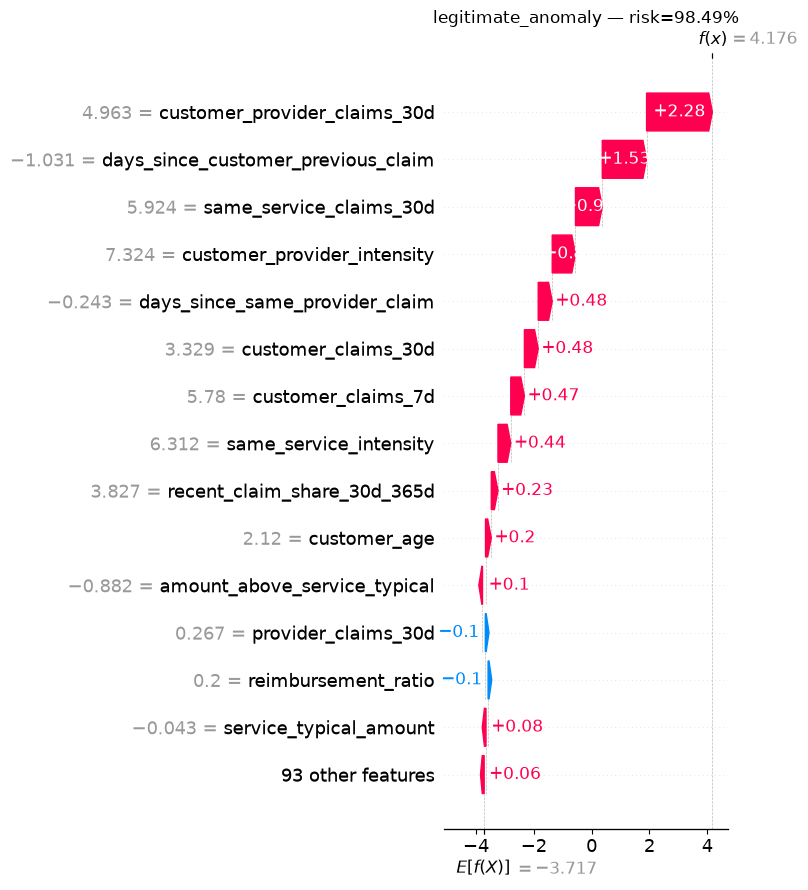

HARD_FRAUD
claim_id                     CLM_00002507
is_fraud                     1
fraud_mechanism              mixed_pattern
fraud_difficulty             hard
legitimate_anomaly           False
legitimate_anomaly_type      none
claim_amount                 175.7
fraud_risk_score             0.9843122363090515


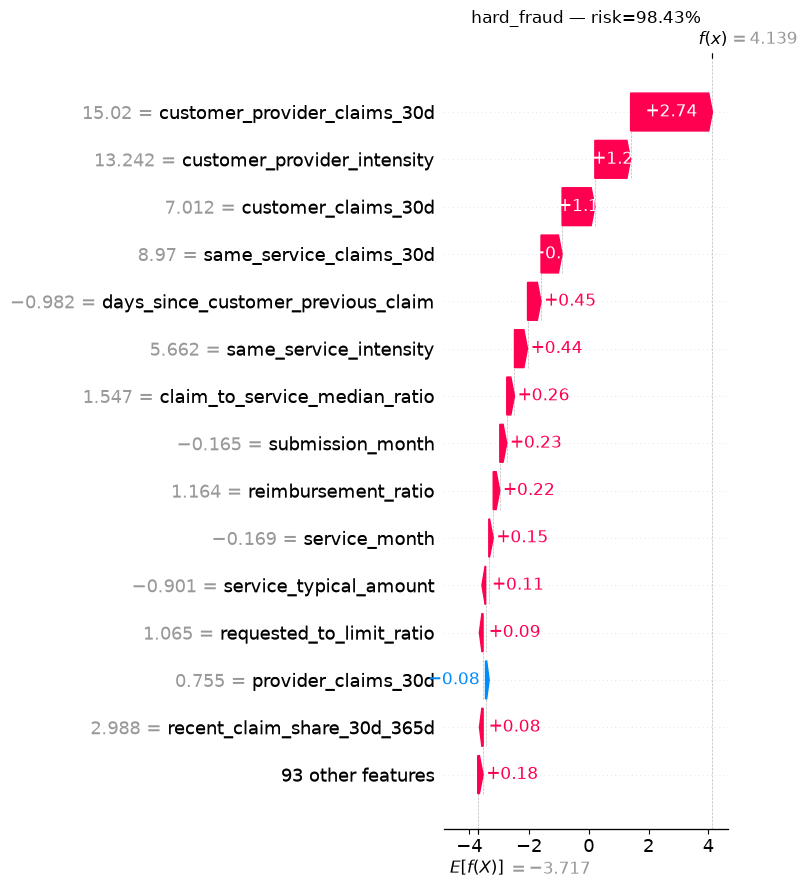

In [20]:
case_metadata_rows = []
case_contribution_frames = []

for (
    case_name,
    row_position,
) in case_definitions:

    metadata_row, contributions = (
        explain_case(
            case_name,
            row_position,
        )
    )

    metadata_row[
        "case_type"
    ] = case_name

    case_metadata_rows.append(
        metadata_row
    )

    contributions[
        "case_type"
    ] = case_name

    case_contribution_frames.append(
        contributions.head(20)
    )

In [21]:
case_metadata_table = pd.DataFrame(
    case_metadata_rows
)

case_metadata_table

,claim_id,is_fraud,fraud_mechanism,fraud_difficulty,legitimate_anomaly,legitimate_anomaly_type,claim_amount,fraud_risk_score,case_type
0,CLM_00080394,1,mixed_pattern,medium,False,none,321.3500,0.9980,true_positive_high_risk
1,CLM_00048120,0,none,none,True,repeated_service_legitimate,70.7700,0.9849,false_positive
2,CLM_00090682,1,repeated_service,easy,False,none,565.2400,0.0031,false_negative
3,CLM_00048120,0,none,none,True,repeated_service_legitimate,70.7700,0.9849,legitimate_anomaly
4,CLM_00002507,1,mixed_pattern,hard,False,none,175.7000,0.9843,hard_fraud


In [22]:
case_metadata_table.to_csv(
    EXPLAINABILITY_DIR
    / "case_explanations_metadata.csv",
    index=False,
)

if case_contribution_frames:
    case_contributions = (
        pd.concat(
            case_contribution_frames,
            ignore_index=True,
        )
    )

    case_contributions.to_csv(
        EXPLAINABILITY_DIR
        / "case_shap_contributions.csv",
        index=False,
    )

## 19. Explain false positives collectively

In [23]:
false_positive_test = (
    test.loc[
        (test[TARGET] == 0)
        & (
            test[
                "reviewed_top3"
            ]
        )
    ]
    .copy()
)

false_positive_profile = pd.Series(
    {
        "false_positive_claims": (
            len(false_positive_test)
        ),
        "share_legitimate_anomalies": (
            false_positive_test[
                "legitimate_anomaly"
            ].mean()
        ),
        "median_risk_score": (
            false_positive_test[
                "fraud_risk_score"
            ].median()
        ),
        "median_claim_amount": (
            false_positive_test[
                "claim_amount"
            ].median()
        ),
    }
)

false_positive_profile

false_positive_claims        206.0000
share_legitimate_anomalies     0.5777
median_risk_score              0.2090
median_claim_amount          212.3700
dtype: float64

In [24]:
false_positive_anomaly_types = (
    false_positive_test[
        "legitimate_anomaly_type"
    ]
    .value_counts(
        dropna=False,
    )
    .to_frame(
        "false_positive_claims"
    )
)

false_positive_anomaly_types

,false_positive_claims
legitimate_anomaly_type,
none,87
repeated_service_legitimate,56
unusual_provider_legitimate,30
high_frequency_legitimate,27
high_amount_legitimate,6


This verifies whether high-risk legitimate claims are mostly random errors or understandable **hard negatives** with genuinely unusual behavior.

## 20. Explain false negatives collectively

In [25]:
false_negative_test = (
    test.loc[
        (test[TARGET] == 1)
        & (
            ~test[
                "reviewed_top3"
            ]
        )
    ]
    .copy()
)

false_negative_by_mechanism = (
    false_negative_test[
        "fraud_mechanism"
    ]
    .value_counts()
    .to_frame(
        "missed_fraud_claims"
    )
)

false_negative_by_mechanism

,missed_fraud_claims
fraud_mechanism,
amount_inflation,69
provider_abnormality,33
frequency_abuse,30
mixed_pattern,26
repeated_service,18
customer_provider_pattern,13


In [26]:
false_negative_by_difficulty = (
    false_negative_test[
        "fraud_difficulty"
    ]
    .value_counts()
    .to_frame(
        "missed_fraud_claims"
    )
)

false_negative_by_difficulty

,missed_fraud_claims
fraud_difficulty,
medium,98
hard,54
easy,37


## 21. Specific diagnosis of `amount_inflation`

In [27]:
amount_inflation = (
    test.loc[
        (test[TARGET] == 1)
        & (
            test[
                "fraud_mechanism"
            ]
            == "amount_inflation"
        )
    ]
    .copy()
)

amount_inflation_summary = pd.Series(
    {
        "claims": len(amount_inflation),
        "mean_score": (
            amount_inflation[
                "fraud_risk_score"
            ].mean()
        ),
        "median_score": (
            amount_inflation[
                "fraud_risk_score"
            ].median()
        ),
        "reviewed_top3_rate": (
            amount_inflation[
                "reviewed_top3"
            ].mean()
        ),
        "median_claim_amount": (
            amount_inflation[
                "claim_amount"
            ].median()
        ),
        "median_claim_to_service_ratio": (
            amount_inflation[
                "claim_to_service_median_ratio"
            ].median()
        ),
        "median_claim_to_customer_ratio": (
            amount_inflation[
                "claim_to_customer_avg_ratio"
            ].median()
        ),
        "median_claim_to_provider_ratio": (
            amount_inflation[
                "claim_to_provider_avg_ratio"
            ].median()
        ),
    }
)

amount_inflation_summary

claims                            75.0000
mean_score                         0.0372
median_score                       0.0200
reviewed_top3_rate                 0.0800
median_claim_amount              254.8600
median_claim_to_service_ratio      1.7167
median_claim_to_customer_ratio     1.3219
median_claim_to_provider_ratio     1.3820
dtype: float64

The goal is not to modify the frozen model here.

The goal is to understand whether amount-inflation fraud is difficult because:

- its amount ratios overlap strongly with legitimate claims;
- legitimate high-amount anomalies create hard negatives;
- other fraud mechanisms produce much stronger behavioral signals;
- the top-3% policy naturally favors concentrated frequency/provider patterns.

## 22. Score distributions — legitimate vs fraud

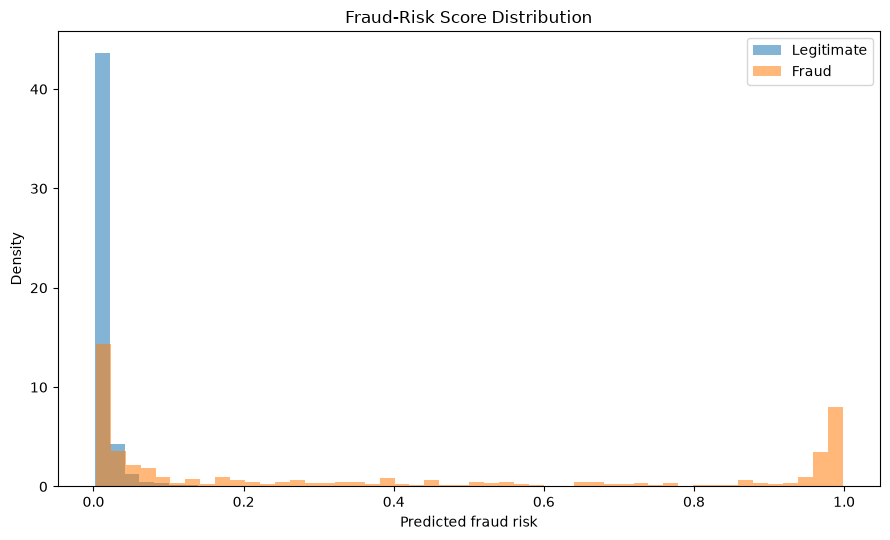

In [28]:
fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

legit_scores = (
    test.loc[
        test[TARGET] == 0,
        "fraud_risk_score",
    ]
)

fraud_scores = (
    test.loc[
        test[TARGET] == 1,
        "fraud_risk_score",
    ]
)

ax.hist(
    legit_scores,
    bins=50,
    density=True,
    alpha=0.55,
    label="Legitimate",
)

ax.hist(
    fraud_scores,
    bins=50,
    density=True,
    alpha=0.55,
    label="Fraud",
)

ax.set_title(
    "Fraud-Risk Score Distribution"
)

ax.set_xlabel(
    "Predicted fraud risk"
)

ax.set_ylabel(
    "Density"
)

ax.legend()

plt.tight_layout()

fig.savefig(
    FIGURES_DIR
    / "04_score_distribution.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

## 23. Save diagnostic tables

In [29]:
mechanism_score_summary.to_csv(
    EXPLAINABILITY_DIR
    / "mechanism_score_summary.csv"
)

difficulty_score_summary.to_csv(
    EXPLAINABILITY_DIR
    / "difficulty_score_summary.csv"
)

false_positive_anomaly_types.to_csv(
    EXPLAINABILITY_DIR
    / "false_positive_anomaly_types.csv"
)

false_negative_by_mechanism.to_csv(
    EXPLAINABILITY_DIR
    / "false_negative_by_mechanism.csv"
)

false_negative_by_difficulty.to_csv(
    EXPLAINABILITY_DIR
    / "false_negative_by_difficulty.csv"
)

print(
    "Explainability artifacts saved."
)

Explainability artifacts saved.


## 24. Executive explainability summary

In [30]:
print("=" * 72)
print("MODEL EXPLAINABILITY SUMMARY")
print("=" * 72)

print(
    f"Model:                        "
    f"{metadata['model_name']}"
)

print(
    f"Explained test claims:        "
    f"{len(test):,}"
)

print(
    f"SHAP sample size:             "
    f"{SHAP_SAMPLE_SIZE:,}"
)

print(
    f"Transformed model features:   "
    f"{len(transformed_feature_names)}"
)

print(
    f"Top business driver:          "
    f"{business_importance.iloc[0]['business_feature']}"
)

print(
    f"False positives:              "
    f"{len(false_positive_test):,}"
)

print(
    f"False negatives:              "
    f"{len(false_negative_test):,}"
)

print(
    f"FP legitimate anomaly share: "
    f"{false_positive_test['legitimate_anomaly'].mean():.2%}"
)

print("=" * 72)

MODEL EXPLAINABILITY SUMMARY
Model:                        XGBoost
Explained test claims:        14,176
SHAP sample size:             5,000
Transformed model features:   107
Top business driver:          claim_to_service_median_ratio
False positives:              206
False negatives:              189
FP legitimate anomaly share: 57.77%


## 25. Business interpretation template

Complete after execution.

### Global explanation

The model's strongest business-level drivers are:

1.
2.
3.
4.
5.

For each driver, describe whether high or low values tend to increase fraud risk.

### High-risk true positive

- Claim:
- Risk score:
- Fraud mechanism:
- Main positive SHAP drivers:
- Business interpretation:

### False positive

- Claim:
- Risk score:
- Legitimate anomaly type:
- Main positive SHAP drivers:
- Why the model's concern was understandable:

### False negative

- Claim:
- Fraud mechanism:
- Difficulty:
- Risk score:
- Why the fraud signal was weak:

### Amount inflation

- Test recall under top-3% review:
- Median risk:
- Main explanation for poor detection:
- Potential future feature-engineering direction:

### Operational conclusion

The score should be used as an **investigation-prioritization signal**, not as an automatic fraud decision.

SHAP explanations provide analysts with the behavioral factors that pushed each claim upward or downward in the investigation queue.

## 26. Explainability governance checklist

- [ ] The frozen model from notebook 05 was used.
- [ ] No retraining occurred.
- [ ] No hyperparameter tuning occurred.
- [ ] No threshold optimization occurred.
- [ ] No leakage feature entered SHAP computation.
- [ ] SHAP feature names match the transformed model matrix.
- [ ] Global explanations were computed.
- [ ] Individual case explanations were computed.
- [ ] True positives were analyzed.
- [ ] False positives were analyzed.
- [ ] False negatives were analyzed.
- [ ] Legitimate anomalies were analyzed.
- [ ] Fraud mechanisms were used only as post-hoc ground truth.
- [ ] `amount_inflation` weakness was explicitly investigated.
- [ ] Explainability artifacts were persisted.